In [17]:
import sys
import os
from tqdm import tqdm
from libs.danbooru_client import create_danbooru_client
from libs.character_search import (
    calculate_average_tag_frequency,
    calculate_gender_frequencies,
)
from dataclasses import dataclass


@dataclass
class TagData:
    tag: str
    female_frequency: float
    male_frequency: float
    is_male: bool
    post_count: int


client = create_danbooru_client()

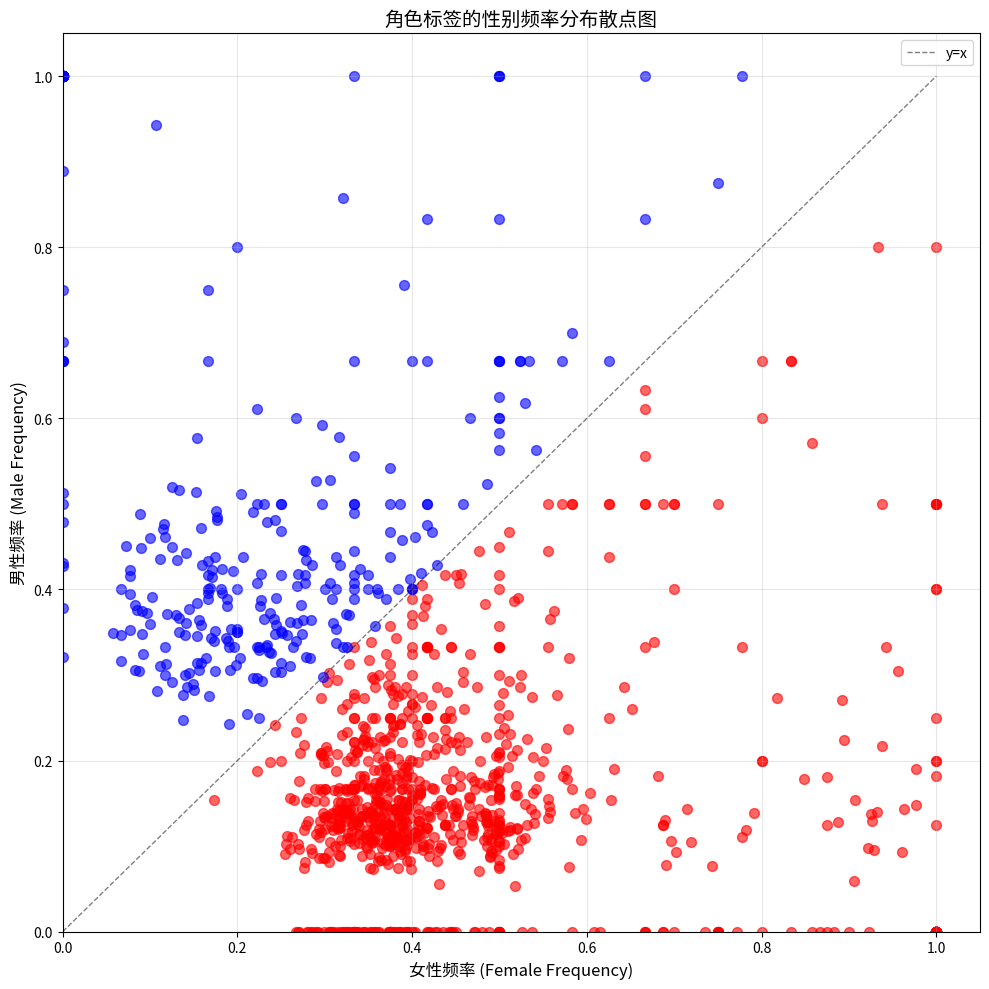

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置全局字体为 Noto Sans CJK SC（简体中文）
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]  # 使用 Noto Sans CJK SC
rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 读取女性数据
tags = []
female_frequency = [[], []]
with open("outputs/arknights_female_characters.csv", "r", encoding="utf-8") as f:
    next(f)  # 跳过标题行
    for line in f:
        split = line.strip().split(",")
        tag = TagData(
            tag=split[0],
            male_frequency=float(split[1]),
            female_frequency=float(split[2]),
            is_male=False,
            post_count=int(split[3]),
        )
        tags.append(tag)
        female_frequency[0].append(tag.male_frequency)
        female_frequency[1].append(tag.female_frequency)

# 读取男性数据
male_frequency = [[], []]
with open("outputs/arknights_male_characters.csv", "r", encoding="utf-8") as f:
    next(f)  # 跳过标题行
    for line in f:
        split = line.strip().split(",")
        tag = TagData(
            tag=split[0],
            male_frequency=float(split[1]),
            female_frequency=float(split[2]),
            is_male=True,
            post_count=int(split[3]),
        )
        tags.append(tag)
        male_frequency[0].append(tag.male_frequency)
        male_frequency[1].append(tag.female_frequency)


# 绘制散点图
plt.figure(figsize=(10, 10))
plt.scatter(female_frequency[1], female_frequency[0], alpha=0.6, s=50, c="red")
plt.scatter(male_frequency[1], male_frequency[0], alpha=0.6, s=50, c="blue")

# 设置坐标轴标签和标题（现在可以正确显示中文）
plt.xlabel("女性频率 (Female Frequency)", fontsize=12)
plt.ylabel("男性频率 (Male Frequency)", fontsize=12)
plt.title("角色标签的性别频率分布散点图", fontsize=14)

plt.grid(True, alpha=0.3)
max_freq = max(
    max(female_frequency[1]) if female_frequency[1] else 0,
    max(female_frequency[0]) if female_frequency[0] else 0,
)
if max_freq > 0:
    plt.plot([0, max_freq], [0, max_freq], "k--", alpha=0.5, linewidth=1, label="y=x")
    plt.legend()
    plt.xlim(0, max_freq * 1.05)
    plt.ylim(0, max_freq * 1.05)


plt.tight_layout()
plt.show()

In [26]:
# 找出性别差异小于0.05的标签
similar_tags = [
    tag for tag in tags if abs(tag.female_frequency - tag.male_frequency) < 0.05
]
# 打印性别差异小于0.05的标签
print("性别差异小于0.05的标签:")
# 按照相差绝对值从大到小排序
similar_tags.sort(
    key=lambda x: abs(x.female_frequency - x.male_frequency), reverse=True
)

for tag in similar_tags:
    print(
        f"{tag.tag}: 女性频率={tag.female_frequency}, 男性频率={tag.male_frequency}, 相差={tag.female_frequency-tag.male_frequency}, 是否男性={tag.is_male}, 总帖子数={tag.post_count}"
    )
print(f"差异小于0.05的标签数: {len(similar_tags)}")

性别差异小于0.05的标签:
sui_(arknights): 女性频率=0.5, 男性频率=0.45, 相差=0.04999999999999999, 是否男性=False, 总帖子数=4
essence_of_evolution_(arknights): 女性频率=0.24999999999999997, 男性频率=0.2, 相差=0.04999999999999996, 是否男性=False, 总帖子数=10
sharp_(arknights): 女性频率=0.3703703703703704, 男性频率=0.32407407407407407, 相差=0.046296296296296335, 是否男性=False, 总帖子数=27
nearl_(shimmering_dew)_(arknights): 女性频率=0.45370370370370366, 男性频率=0.4074074074074074, 相差=0.04629629629629628, 是否男性=False, 总帖子数=81
male_doctor_(arknights): 女性频率=0.3247064462017733, 男性频率=0.3709561466570812, 相差=-0.04624970045530791, 是否男性=True, 总帖子数=1391
thermal-ex_(arknights): 女性频率=0.5111111111111112, 男性频率=0.4666666666666667, 相差=0.04444444444444451, 是否男性=False, 总帖子数=15
yith_(arknights): 女性频率=0.4222222222222222, 男性频率=0.4666666666666666, 相差=-0.0444444444444444, 是否男性=True, 总帖子数=15
lee_(arknights): 女性频率=0.2106027596223675, 男性频率=0.25441781650931977, 相差=-0.04381505688695228, 是否男性=True, 总帖子数=459
castle-3_(arknights): 女性频率=0.41269841269841273, 男性频率=0.36904761904761907, 相差=0.04